Guardado: wilcoxon_pvalues.csv

Ganadores (no derrotados) α=0.05:
 - WF_02
 - WF_04
 - WF_07


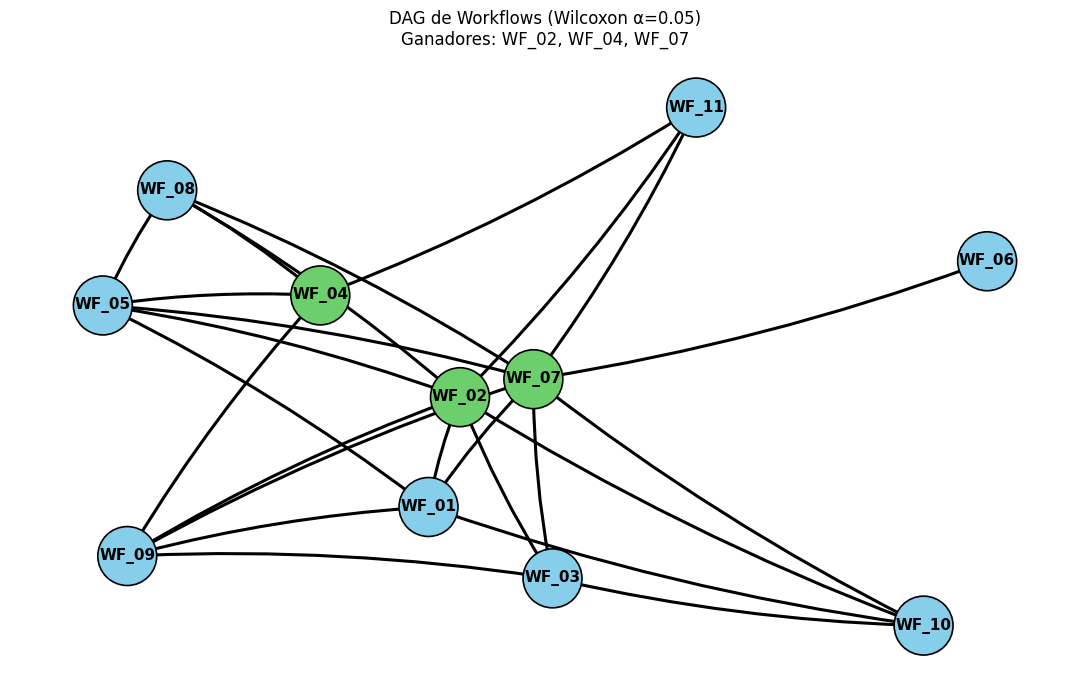

Guardado: DAG_Wilcoxon.png


In [2]:
# -*- coding: utf-8 -*-
# Wilcoxon pareado + DAG de ganadores (flechas claras y ganadores en verde)

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import networkx as nx

# ---------- CONFIG ----------
PATH_IN = r"C:\Users\Luis\Documents\dm2025\Experimento colaborativo FEHistorico\TABLA.xlsx"
CSV_OUT = "wilcoxon_pvalues.csv"
PNG_OUT = "DAG_Wilcoxon.png"
ALPHA = 0.05
# ---------------------------

# 1) Leer el Excel (tu archivo viene con encabezados en filas)
raw = pd.read_excel(PATH_IN, header=None, engine="openpyxl")

# 2) Ubicar la fila "Semillas" y las columnas de semillas
semillas_row = raw.index[
    raw.apply(lambda r: r.astype(str).str.contains("Semillas", case=False, na=False).any(), axis=1)
][0]
sem_row = semillas_row + 1  # fila donde están los IDs de semillas

# detectar desde qué columna empiezan las semillas
seed_start_col = None
for j in range(raw.shape[1]):
    v = raw.iloc[sem_row, j]
    if pd.notna(v):
        try:
            float(str(v).replace(".", "").replace(",", "."))
            seed_start_col = j
            break
        except:
            pass
if seed_start_col is None:
    raise RuntimeError("No pude detectar columnas de semillas.")

# columnas de semillas contiguas
seed_cols = []
for j in range(seed_start_col, raw.shape[1]):
    if pd.isna(raw.iloc[sem_row, j]): break
    seed_cols.append(j)

# 3) Extraer filas de Workflows (nombre en col 2; valores en seed_cols)
def to_num(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace(".", "").replace(",", ".")
    try: return float(s)
    except: return np.nan

wf_start = sem_row + 1
wf_name_col = 2
wf_data = {}
for i in range(wf_start, raw.shape[0]):
    name = raw.iloc[i, wf_name_col]
    if pd.isna(name): 
        continue
    name = str(name).strip()
    if not name.upper().startswith("WF"):
        continue
    vals = [to_num(x) for x in raw.iloc[i, seed_cols].tolist()]
    if all(pd.isna(vals)): 
        continue
    wf_data[name] = vals

if not wf_data:
    raise RuntimeError("No se detectaron filas de WF (WF_01, WF_02, ...).")

W = pd.DataFrame(wf_data, index=[raw.iloc[sem_row, j] for j in seed_cols])

# 4) Test de Wilcoxon pareado (H1: wi > wj) con manejo de empates
def wilcoxon_p_greater(vec_i, vec_j):
    a = np.array(vec_i, dtype=float)
    b = np.array(vec_j, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(b)
    a, b = a[mask], b[mask]
    if len(a) == 0 or len(a) != len(b):
        return np.nan
    d = a - b
    if np.allclose(d, 0):  # todo igual
        return 1.0
    try:
        return wilcoxon(a, b, alternative="greater", zero_method="pratt").pvalue
    except ValueError:
        eps = 1e-9
        return wilcoxon(a + eps, b, alternative="greater", zero_method="pratt").pvalue

# 5) P-valores par a par
pairs = []
cols = list(W.columns)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        wi, wj = cols[i], cols[j]
        p_ij = wilcoxon_p_greater(W[wi], W[wj])  # H1: wi > wj
        p_ji = wilcoxon_p_greater(W[wj], W[wi])  # H1: wj > wi
        pairs.append((wi, wj, p_ij, p_ji))

res = pd.DataFrame(pairs, columns=["wf_i","wf_j","p_wf_i_greater_wf_j","p_wf_j_greater_wf_i"])
res.to_csv(CSV_OUT, index=False)
print("Guardado:", CSV_OUT)

# 6) Aristas ganador→perdedor: si p<α, agrego flecha. Si hay contradicción, dejo la de menor p.
edge_p = {}
for _, r in res.iterrows():
    wi, wj = r["wf_i"], r["wf_j"]
    p_ij, p_ji = r["p_wf_i_greater_wf_j"], r["p_wf_j_greater_wf_i"]
    if pd.notna(p_ij) and p_ij < ALPHA: edge_p[(wi, wj)] = float(p_ij)
    if pd.notna(p_ji) and p_ji < ALPHA: edge_p[(wj, wi)] = float(p_ji)

edges = set(edge_p)
kill = set()
for (a,b) in list(edges):
    if (b,a) in edges:
        kill.add((b,a) if edge_p[(a,b)] <= edge_p[(b,a)] else (a,b))
edges -= kill

# 7) Grafo con flechas bien visibles y ganadores en verde (no derrotados = sin flechas entrantes)
G = nx.DiGraph()
G.add_nodes_from(cols)
G.add_edges_from(edges)

no_derrotas = sorted([n for n in G.nodes if G.in_degree(n) == 0])
print("\nGanadores (no derrotados) α=%.2f:" % ALPHA)
for g in no_derrotas:
    print(" -", g)

plt.figure(figsize=(11, 7))
pos = nx.spring_layout(G, seed=7, k=0.8)

# Coloreo: ganadores en verde, resto celeste
node_colors = ["#6CCF6C" if n in no_derrotas else "#87CEEB" for n in G.nodes]

# Nodos
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, edgecolors="black",
    node_size=1800, linewidths=1.2
)
# Etiquetas
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")

# Aristas con flechas notorias
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowstyle="-|>",   # punta clara
    arrowsize=18,       # tamaño de flecha
    width=2.2,
    connectionstyle="arc3,rad=0.05"  # leve curvatura para que se vean separadas
)

plt.title(f"DAG de Workflows (Wilcoxon α={ALPHA})\nGanadores: {', '.join(no_derrotas) if no_derrotas else 'Ninguno'}")
plt.axis("off")
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=220)
plt.show()
print("Guardado:", PNG_OUT)
